In [31]:
import matplotlib.pyplot as plt
from keras.layers import Input, Rescaling, ReLU, Dense, Conv2D, Flatten, Dropout, BatchNormalization, MaxPooling2D, RandomFlip, RandomRotation, RandomZoom, RandomTranslation, GlobalAveragePooling2D
from keras.utils import image_dataset_from_directory
from keras.models import Sequential

In [ ]:
# 1. Load the Training Dataset (80%)
train_dataset = image_dataset_from_directory(
    directory='data/data',
    labels='inferred',
    label_mode='int',
    color_mode='rgb',
    batch_size=64,
    image_size=(224, 224),
    shuffle=True,
    seed=42, 
    validation_split=0.2,
    subset='training'
)

# 2. Load the Validation Dataset (20%)
val_dataset = image_dataset_from_directory(
    directory='data/data/',
    labels='inferred',
    label_mode='int',
    color_mode='rgb',
    batch_size=64,
    image_size=(224, 224),
    shuffle=True,    
    seed=42,         
    validation_split=0.2,
    subset='validation' 
)

Found 4317 files belonging to 5 classes.
Using 3454 files for training.
Found 4317 files belonging to 5 classes.
Using 863 files for validation.


In [ ]:
model = Sequential()
model.add(Input(shape=(224, 224, 3)))

model.add(Rescaling(1./255))

model.add(RandomFlip("horizontal"))
model.add(RandomRotation(0.1))
model.add(RandomZoom(0.1))
model.add(RandomTranslation(0.1, 0.1))

# Block 1: 224x224 -> 112x112
model.add(Conv2D(32, (3, 3), padding='same'))
model.add(BatchNormalization())
model.add(ReLU())
model.add(MaxPooling2D((2, 2)))
model.add(Dropout(0.2))

# Block 2: 112x112 -> 56x56
model.add(Conv2D(64, (3, 3), padding='same'))
model.add(BatchNormalization())
model.add(ReLU())
model.add(MaxPooling2D((2, 2)))
model.add(Dropout(0.25))

# Block 3: 56x56 -> 28x28
model.add(Conv2D(128, (3, 3), padding='same'))
model.add(BatchNormalization())
model.add(ReLU())
model.add(MaxPooling2D((2, 2)))
model.add(Dropout(0.3))

# Block 4: 28x28 -> 14x14
model.add(Conv2D(128, (3, 3), padding='same'))
model.add(BatchNormalization())
model.add(ReLU())
model.add(MaxPooling2D((2, 2)))
model.add(Dropout(0.3))

model.add(Flatten())
model.add(Dense(128))
model.add(BatchNormalization())
model.add(ReLU())
model.add(Dropout(0.4))
model.add(Dense(5, activation='softmax'))

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_4 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_flip_4 (RandomFlip)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation_4               │ (None, 224, 224, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom_4 (RandomZoom)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_translation_4            │ (None, 224, 224, 3)    │             0 │
│ (RandomTranslation)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_20          │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_20 (ReLU)                 │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_20 (Dropout)            │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_21          │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_21 (ReLU)                 │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_21 (Dropout)            │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_22          │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_22 (ReLU)                 │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_18 (MaxPooling2D) │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_22 (Dropout)            │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 28, 28, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_23          │ (None, 28, 28, 128)    │           512 │
│ (BatchNormalization)            │                        │             

 Total params: 3,454,789 (13.18 MB)

 Trainable params: 3,453,829 (13.18 MB)

 Non-trainable params: 960 (3.75 KB)

In [24]:
import tensorflow as tf
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))

Num GPUs Available:  1


In [26]:
from keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=7,             # Number of epochs to wait before cutting it off
    restore_best_weights=True
)
history = model.fit(train_dataset, epochs=50, validation_data=val_dataset, callbacks=[early_stop], verbose = 1)

Epoch 1/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 18s 330ms/step - accuracy: 0.5266 - loss: 1.1842 - val_accuracy: 0.2387 - val_loss: 2.0622
Epoch 2/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 17s 320ms/step - accuracy: 0.5553 - loss: 1.1092 - val_accuracy: 0.2387 - val_loss: 2.2869
Epoch 3/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 18s 335ms/step - accuracy: 0.5984 - loss: 1.0328 - val_accuracy: 0.2387 - val_loss: 2.3546
Epoch 4/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 18s 325ms/step - accuracy: 0.6187 - loss: 0.9714 - val_accuracy: 0.2399 - val_loss: 2.1509
Epoch 5/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 18s 336ms/step - accuracy: 0.6485 - loss: 0.9012 - val_accuracy: 0.2445 - val_loss: 2.1267
Epoch 6/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 18s 330ms/step - accuracy: 0.6737 - loss: 0.8616 - val_accuracy: 0.4218 - val_loss: 1.5393
Epoch 7/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 18s 326ms/step - accuracy: 0.6925 - loss: 0.8245 - val_accuracy: 0.3488 - val_loss: 1.7515
Epoch 8/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 18s 329ms/step - accuracy: 0.6934 - loss: 0.7996 - val_accu

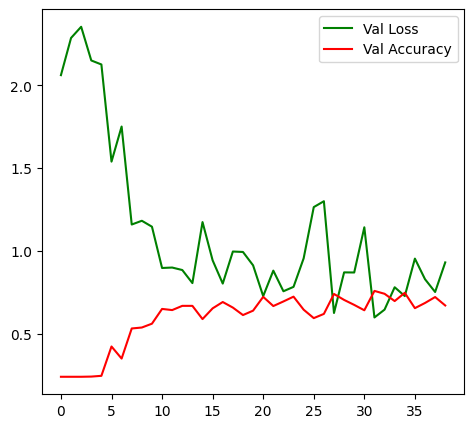

In [30]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['val_loss'],label='Val Loss', color='green')
plt.plot(history.history['val_accuracy'], label='Val Accuracy',color='red')
plt.legend()
plt.show()